# Telco Customer Churn Analysis and Prediction

## By Atharva Salitri

### a. Project Overview
This project focuses on analyzing customer churn in a telecommunications company. Customer churn, the phenomenon of customers discontinuing their service, is a critical business problem for Telco companies as it directly impacts revenue and profitability. By understanding the factors contributing to churn, the company can develop targeted strategies to retain valuable customers.

### b. Dataset
The dataset used for this analysis is the `Telco Customer Churn` dataset, which contains information about 7,032 customers. It includes 20 features covering demographic information, services subscribed to, contract details, and payment information, along with a `Churn` target variable indicating whether a customer left the company.

### c. Problem Statement
The primary goal is to identify factors influencing customer churn and build predictive models to accurately forecast which customers are likely to churn. This will enable the Telco company to proactively intervene with retention strategies.

### d. Objectives
-   **Data Understanding and Cleaning**: Explore the dataset, identify data quality issues, and preprocess the data for analysis.
-   **Exploratory Data Analysis (EDA) & Visualization**: Uncover patterns, relationships, and key drivers of churn through comprehensive data visualization.
-   **Machine Learning Modeling**: Train and evaluate several classification models to predict customer churn.
-   **Business Insights & Recommendations**: Translate analytical findings into actionable business strategies to reduce churn.

## Code and Analysis:

### 1. Importing Libraries and Loading Data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Telco-Customer-Churn.csv')


### 2. Data Understanding

Let's get a basic understanding of the dataset by looking at the first few rows, checking data types, and summary statistics.

In [14]:
print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe(include='all'))

print("\nDataset Shape:", df.shape)


First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN



Dataset Shape: (7043, 21)


### 3. Data Cleaning and Preprocessing

Based on the initial inspection, we need to address a few things:
- The `TotalCharges` column is of object type, but should be numeric. We'll convert it and handle any errors.
- Check for and handle missing values.
- Drop the `customerID` column as it's not relevant for prediction.

In [15]:
# Convert 'TotalCharges' to numeric. Coerce errors will turn non-numeric values into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values after conversion
print("Missing values after converting TotalCharges:")
print(df.isnull().sum())

# Drop rows with missing TotalCharges (which were ' ' in the original dataset)
df.dropna(inplace=True)
print("\nDataset Shape after dropping nulls:", df.shape)

# Drop customerID column
df.drop('customerID', axis=1, inplace=True)
print("\nDropped 'customerID' column.")

# Display data types after cleaning
print("\nData types after cleaning:")
df.info()

Missing values after converting TotalCharges:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Dataset Shape after dropping nulls: (7032, 21)

Dropped 'customerID' column.

Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents

### 4. Target Variable Analysis (Churn)

Let's analyze the distribution of our target variable, `Churn`, to understand the class imbalance.

Distribution of Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage of Churn:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


/tmp/ipykernel_530/1267961077.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


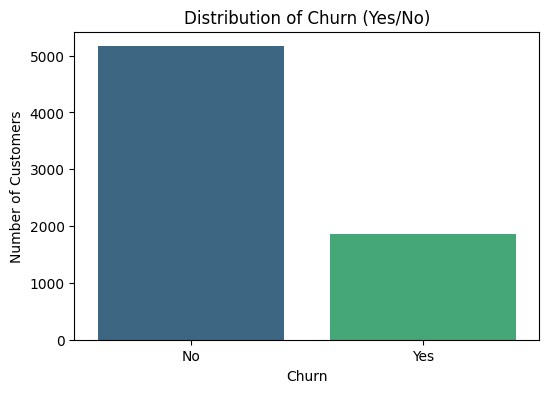

In [16]:
print("Distribution of Churn:")
print(df['Churn'].value_counts())
print("\nPercentage of Churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Churn (Yes/No)')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

### 5. Data Visualization - Exploring Categorical Features vs. Churn

Let's visualize the relationship between categorical features and the 'Churn' variable using count plots.

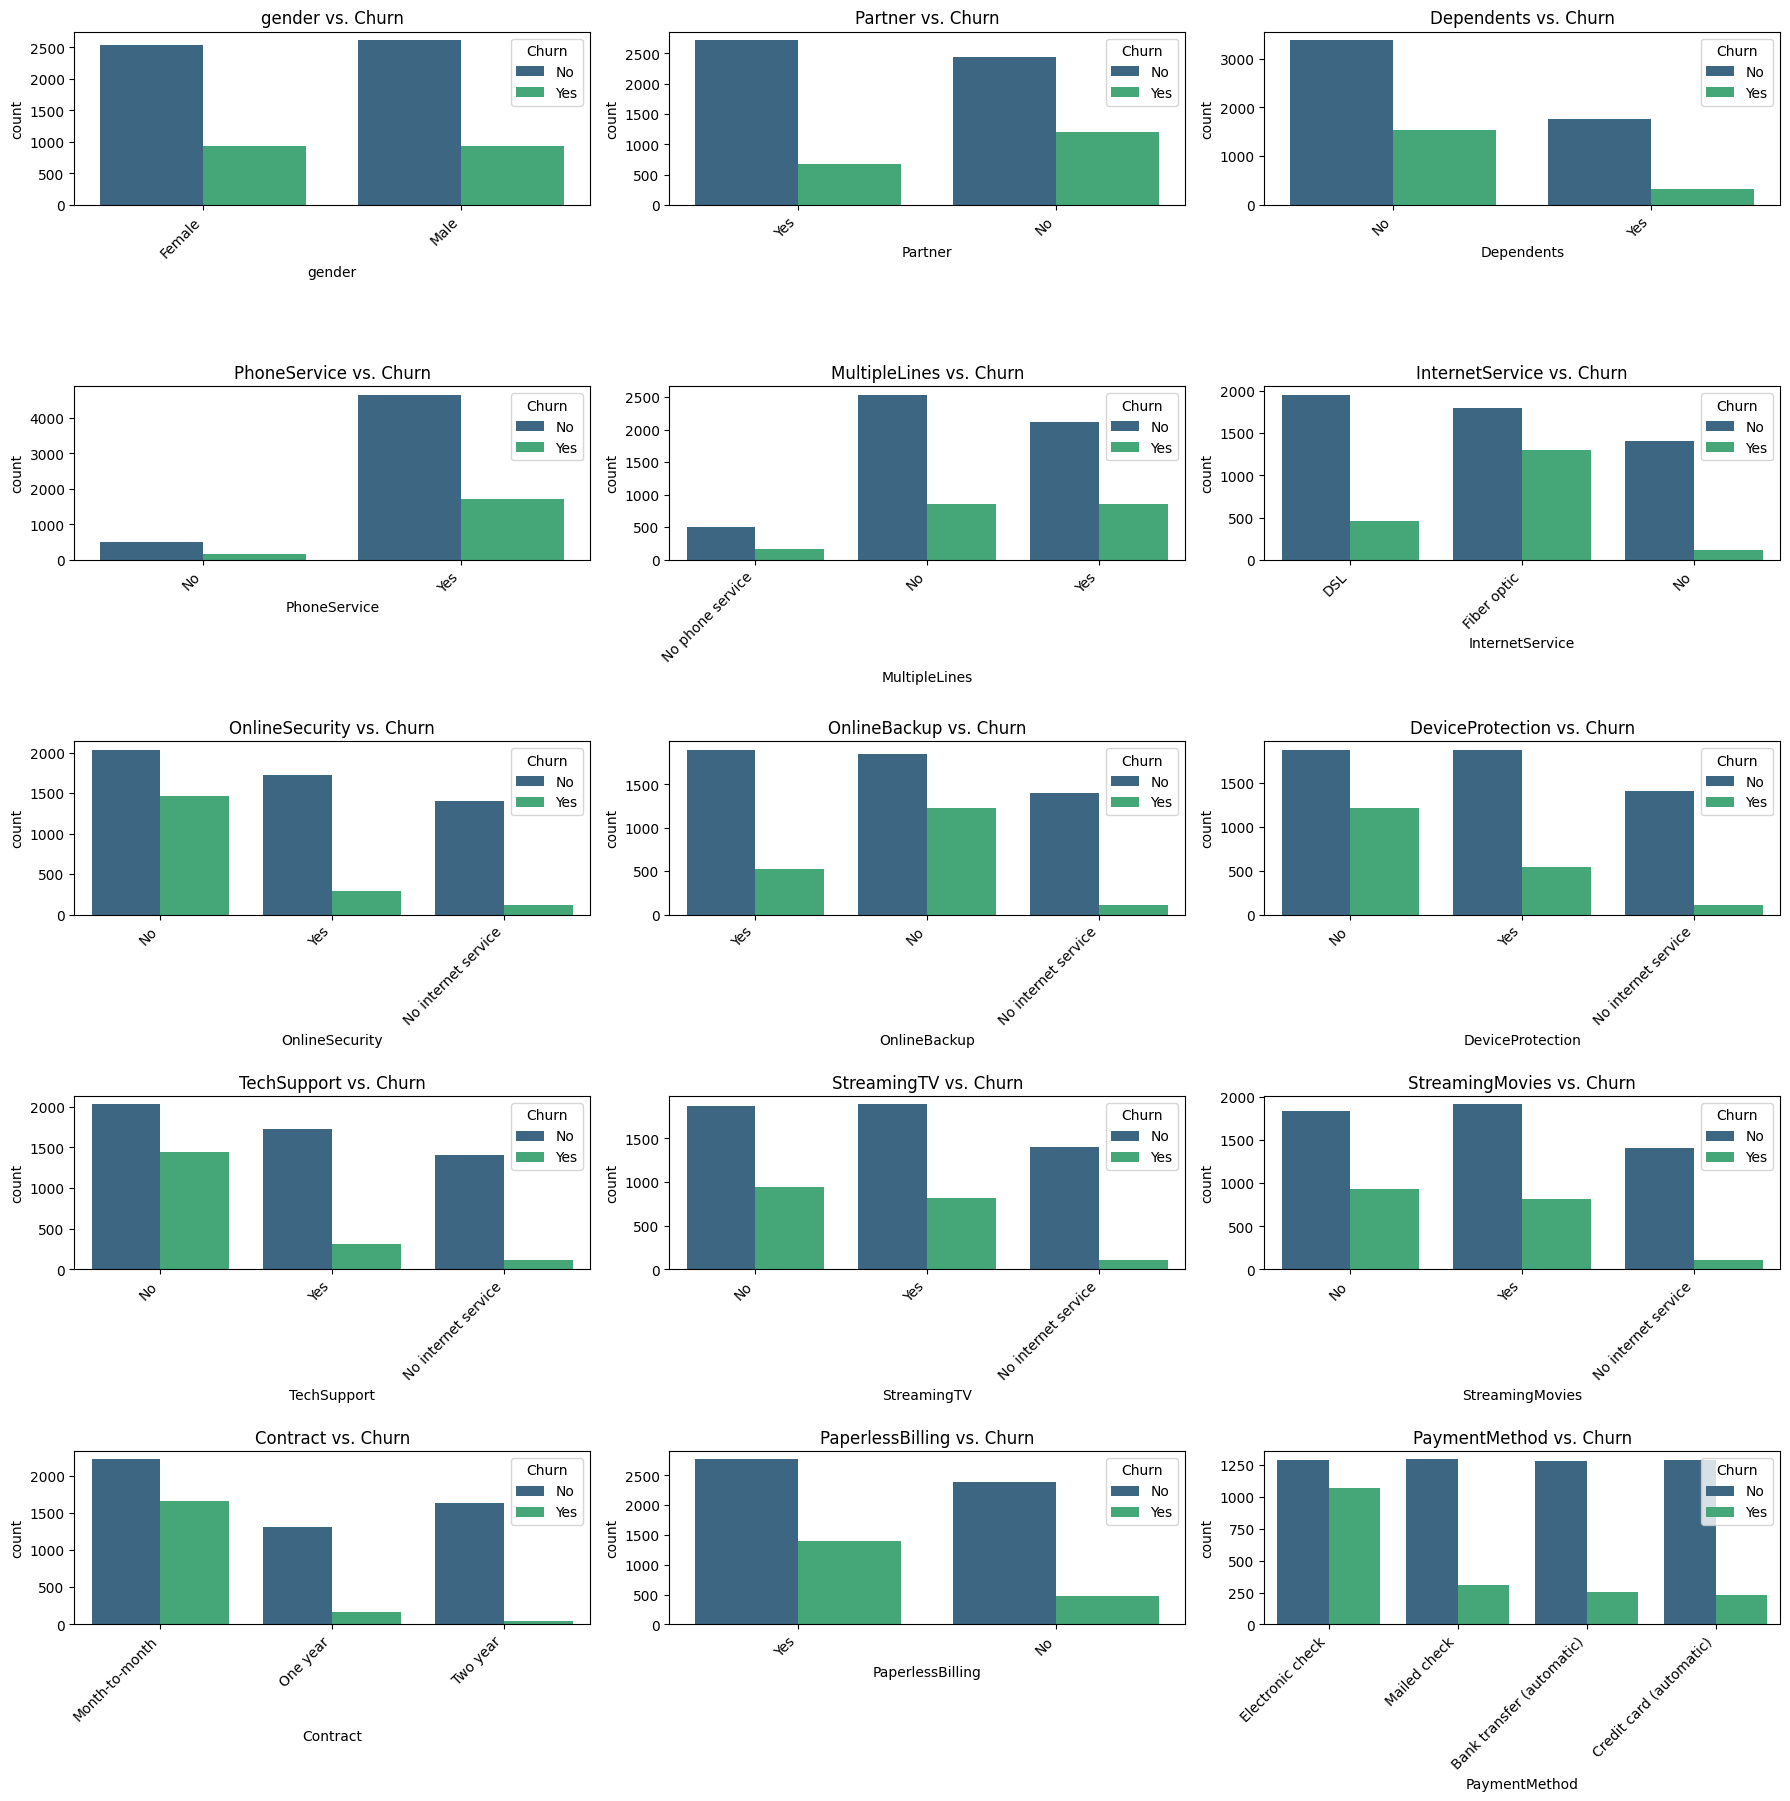

In [17]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn') # Exclude the target variable

plt.figure(figsize=(18, 20))
for i, col in enumerate(categorical_cols):
    plt.subplot(6, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=col, hue='Churn', data=df, palette='viridis')
    plt.title(f'{col} vs. Churn')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
plt.show()

In [41]:
print('Churn percentages by SeniorCitizen:')
display(df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100)

print('\nChurn percentages by Partner:')
display(df.groupby('Partner')['Churn'].value_counts(normalize=True).unstack() * 100)

print('\nChurn percentages by Dependents:')
display(df.groupby('Dependents')['Churn'].value_counts(normalize=True).unstack() * 100)

print('\nChurn percentages by InternetService:')
display(df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100)

print('\nChurn percentages by OnlineSecurity:')
display(df.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True).unstack() * 100)

print('\nChurn percentages by TechSupport:')
display(df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100)

print('\nChurn percentages by Contract:')
display(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100)

print('\nChurn percentages by PaperlessBilling:')
display(df.groupby('PaperlessBilling')['Churn'].value_counts(normalize=True).unstack() * 100)

print('\nChurn percentages by PaymentMethod:')
display(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100)

print('\nChurn percentages for Gender:')
display(df.groupby('gender')['Churn'].value_counts(normalize=True).unstack() * 100)


Churn percentages by SeniorCitizen:


Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261



Churn percentages by Partner:


Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065



Churn percentages by Dependents:


...

Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251



Churn percentages by PaymentMethod:


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995



Churn percentages for Gender:


Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


### Insights from Categorical Feature Visualization

- **Gender**: There appears to be no significant difference in churn rates between male (**26.63%** churn) and female (**26.53%** churn) customers.
- **SeniorCitizen**: Senior citizens (**41.68%** churn) show a significantly higher churn rate compared to non-senior citizens (**23.65%** churn).
- **Partner, Dependents**: Customers without partners (**32.98%** churn) or dependents (**31.39%** churn) tend to churn more, suggesting that single customers or those without family responsibilities might be less tied to the service.
- **PhoneService**: While the vast majority of customers have phone service, customers *without* phone service have a **23.09%** churn rate, slightly lower than those with phone service (**26.92%** churn). This difference is not as stark as other features.
- **MultipleLines**: Customers with multiple lines (**28.69%** churn) churn slightly more than those with a single line (**24.99%** churn), but the difference is not extremely pronounced.
- **InternetService**: Customers with Fiber optic internet service have a significantly higher churn rate (**41.88%** churn) compared to DSL (**18.96%** churn) or no internet service (**7.49%** churn). This could indicate dissatisfaction with Fiber optic service quality or higher pricing.
- **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies**: Customers who do **not** have these services (e.g., Online Security: **42.14%** churn; Tech Support: **42.06%** churn) show considerably higher churn rates. This suggests that these supplementary services act as retention factors. Conversely, streaming services (TV and Movies) don't show as strong a relationship, with churn being somewhat balanced.
- **Contract**: Month-to-month contract customers have a much higher churn rate (**42.71%** churn) than those with one-year (**11.25%** churn) or two-year contracts (**3.66%** churn), indicating that longer-term contracts are effective for retention.
- **PaperlessBilling**: Customers with paperless billing (**33.73%** churn) have a higher churn rate compared to those without (**16.33%** churn), which might suggest they are more tech-savvy and willing to switch providers.
- **PaymentMethod**: Electronic check users have the highest churn rate (**45.33%** churn), which could be due to ease of switching or specific demographics using this payment method, compared to other methods like Bank transfer (automatic) at **16.71%** churn, Credit card (automatic) at **16.01%** churn, and Mailed check at **20.97%** churn.

### 6. Data Visualization - Exploring Numerical Features vs. Churn

Let's visualize the distribution of numerical features and their relationship with 'Churn'.

/tmp/ipykernel_530/1562429310.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x=col, kde=True, palette='viridis')
/tmp/ipykernel_530/1562429310.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='viridis')
/tmp/ipykernel_530/1562429310.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x=col, kde=True, palette='viridis')
/tmp/ipykernel_530/1562429310.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='viridis')
/tmp/ipykernel_530/1562429310.py:6: UserWarning: Ignoring `palette` because no `hue` variable 

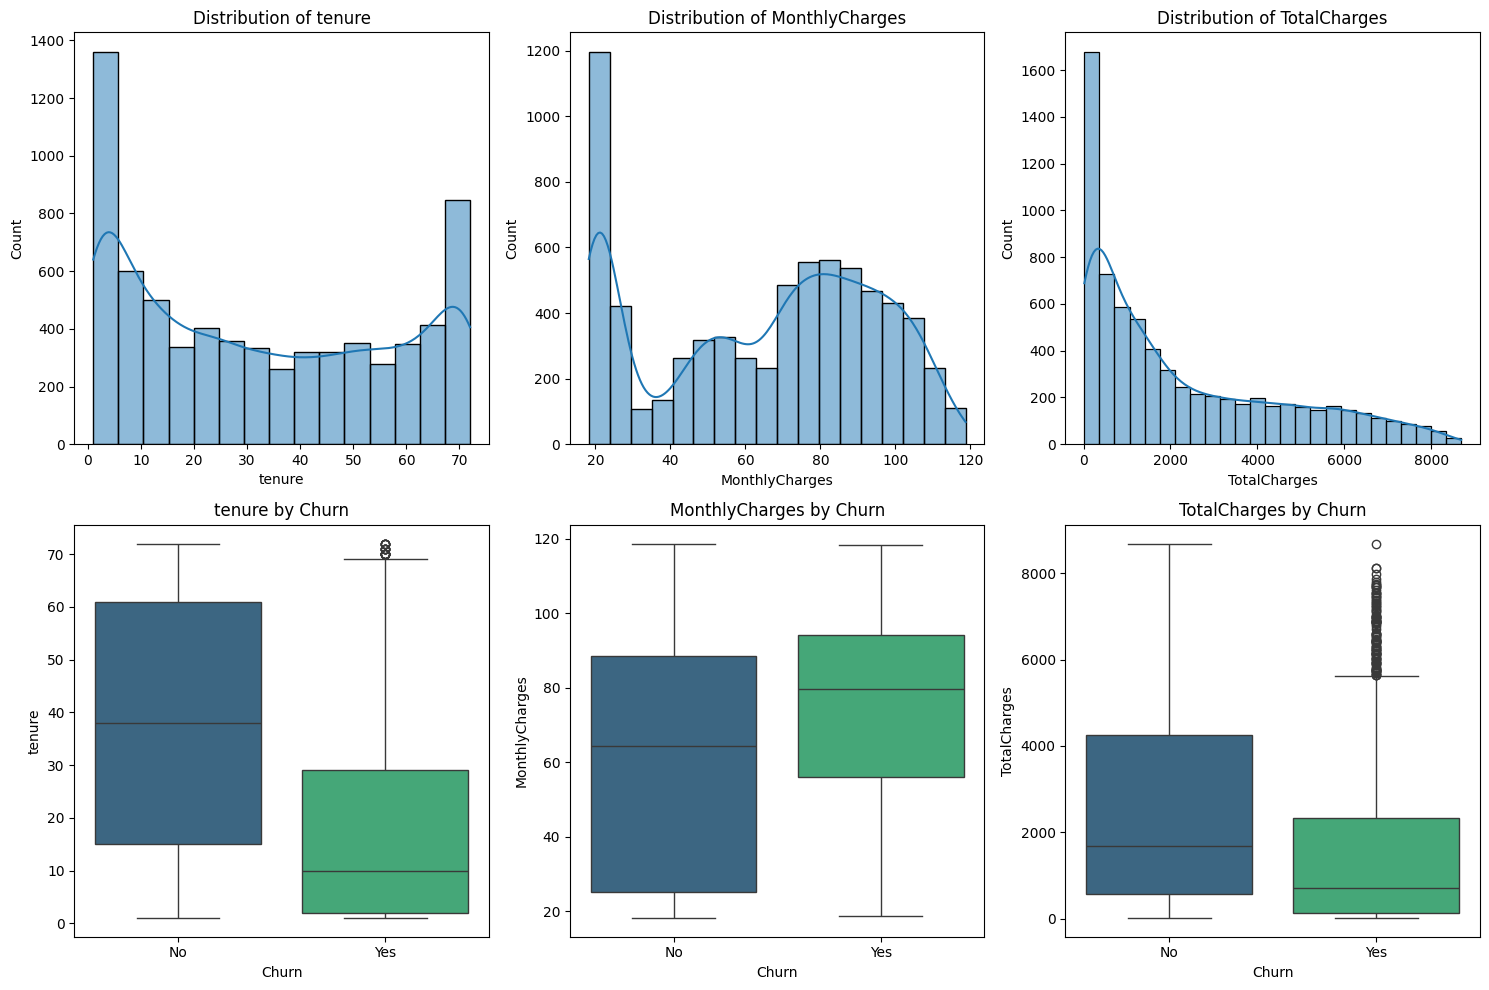

In [18]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Histogram for overall distribution
    sns.histplot(data=df, x=col, kde=True, palette='viridis')
    plt.title(f'Distribution of {col}')

    plt.subplot(2, 3, i + 4) # Box plot for churn comparison
    sns.boxplot(data=df, x='Churn', y=col, palette='viridis')
    plt.title(f'{col} by Churn')
plt.tight_layout()
plt.show()

### Insights from Numerical Feature Visualization

- **Tenure**: Customers with lower `tenure` (newer customers) have a much higher churn rate. As `tenure` increases, the likelihood of churn decreases significantly. This indicates that long-term customers are more loyal.
- **MonthlyCharges**: Customers with higher `MonthlyCharges` tend to churn more. This suggests that expensive plans might be a contributing factor to churn.
- **TotalCharges**: The distribution of `TotalCharges` shows that churning customers often have lower `TotalCharges` compared to non-churning customers, which aligns with the observation that new customers churn more. Non-churning customers show a wider range and higher median `TotalCharges`.

### Advanced Data Visualisations:

#### 6.1 Overall Churn Distribution

In [42]:
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

fig = px.pie(names=churn_counts.index, values=churn_counts.values,
             title='<b>Overall Churn Distribution</b>',
             color_discrete_sequence=px.colors.sequential.Viridis_r,
             hole=0.3)

fig.update_traces(textinfo='percent+label', marker=dict(line=dict(color='#000000', width=2)))
fig.update_layout(width=700, height=500,
                  annotations=[dict(text=f'Total Customers: {len(df)}', x=0.5, y=0.5, font_size=15, showarrow=False)])
fig.show()

print(f"Overall Churn Rate: {churn_percentage['Yes']:.2f}%")
print(f"Overall Non-Churn Rate: {churn_percentage['No']:.2f}%")

Overall Churn Rate: 26.58%
Overall Non-Churn Rate: 73.42%


#### Business Insights: Overall Churn Distribution

- **Significant Churn Rate**: The overall churn rate is approximately **26.58%**, meaning more than a quarter of the customer base churns. This represents a substantial loss of revenue and indicates a need for targeted retention strategies.
- **Class Imbalance**: The dataset exhibits a class imbalance, with **73.42%** of customers not churning and **26.58%** churning. This imbalance needs to be considered during model training and evaluation, as models might be biased towards predicting the majority class (No Churn).

#### 6.2 Churn Distribution by Gender

In [59]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

g_labels = ['Male', 'Female']
c_labels = ['No', 'Yes']

# Create subplots: use 'domain' type for Pie subplot
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]])
fig.add_trace(go.Pie(labels=g_labels, values=df['gender'].value_counts(), name="Gender"),
              1, 1)
fig.add_trace(go.Pie(labels=c_labels, values=df['Churn'].value_counts(), name="Churn"),
              1, 2)

# Use `hole` to create a donut-like pie chart
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)

fig.update_layout(
    title_text="Gender and Churn Distributions",
    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Gender', x=0.16, y=0.5, font_size=20, showarrow=False),
                 dict(text='Churn', x=0.84, y=0.5, font_size=20, showarrow=False)])
fig.show()


Number of Non-Churning Customers by Gender:


,Churn
gender,
Female,2544
Male,2619



Number of Churning Customers by Gender:


,Churn
gender,
Female,939
Male,930


<Figure size 800x800 with 0 Axes>

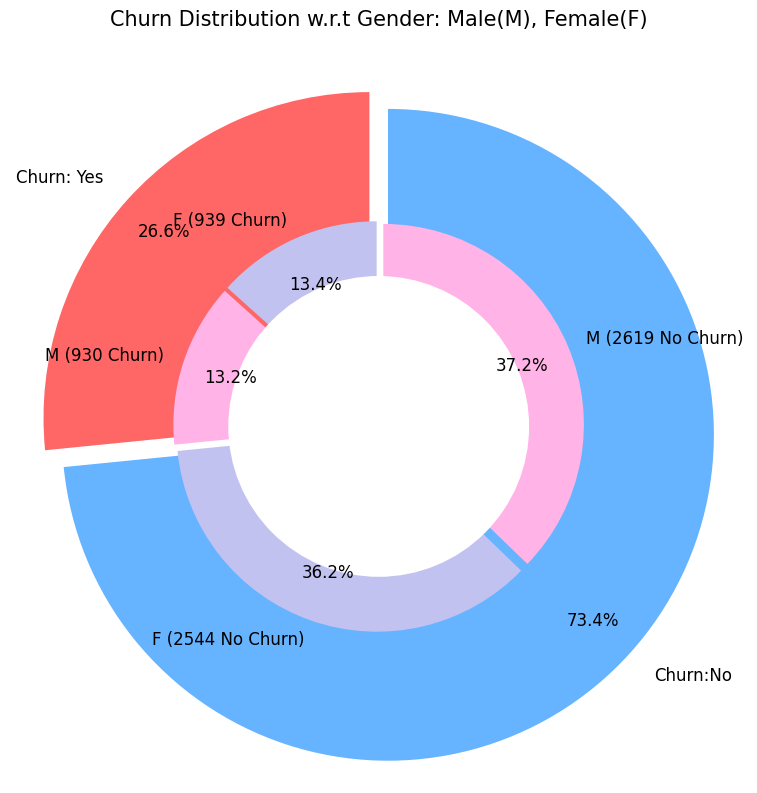

In [60]:
print("Number of Non-Churning Customers by Gender:")
display(df[df["Churn"]=="No"].groupby(by=df["gender"]).count()['Churn'])

print("\nNumber of Churning Customers by Gender:")
display(df[df["Churn"]=="Yes"].groupby(by=df["gender"]).count()['Churn'])

plt.figure(figsize=(8, 8))
labels =["Churn: Yes","Churn:No"]
values = [df['Churn'].value_counts()['Yes'], df['Churn'].value_counts()['No']]

# Get counts for gender within churn categories
churn_yes_gender = df[df['Churn'] == 'Yes']['gender'].value_counts()
churn_no_gender = df[df['Churn'] == 'No']['gender'].value_counts()

labels_gender = []
sizes_gender = []

# Order: Female Churn, Male Churn, Female No Churn, Male No Churn
labels_gender.append(f"F ({churn_yes_gender.get('Female', 0)} Churn)")
sizes_gender.append(churn_yes_gender.get('Female', 0))
labels_gender.append(f"M ({churn_yes_gender.get('Male', 0)} Churn)")
sizes_gender.append(churn_yes_gender.get('Male', 0))

labels_gender.append(f"F ({churn_no_gender.get('Female', 0)} No Churn)")
sizes_gender.append(churn_no_gender.get('Female', 0))
labels_gender.append(f"M ({churn_no_gender.get('Male', 0)} No Churn)")
sizes_gender.append(churn_no_gender.get('Male', 0))

colors = ['#ff6666', '#66b3ff'] # Colors for Churn Yes/No
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6'] # Colors for gender within churn categories
explode = (0.05,0.05)
explode_gender = (0.02,0.02,0.02,0.02)
textprops = {"fontsize":12}

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Outer pie chart for Churn Yes/No
wedges, texts, autotexts = ax.pie(values, autopct='%1.1f%%', pctdistance=0.85, labels=labels, colors=colors, startangle=90, frame=True, explode=explode, radius=1.3, textprops=textprops, counterclock=True)

# Inner pie chart for Gender within Churn Yes/No
wedges_gender, texts_gender, autotexts_gender = ax.pie(sizes_gender, autopct='%1.1f%%', pctdistance=0.75, labels=labels_gender, colors=colors_gender, startangle=90, explode=explode_gender, radius=0.8, textprops=textprops, counterclock=True)

# Draw circle
centre_circle = plt.Circle((0,0),0.6,color='black', fc='white',linewidth=0)
fig.gca().add_artist(centre_circle)

plt.title('Churn Distribution w.r.t Gender: Male(M), Female(F)', fontsize=15, y=1.05)
plt.axis('equal')
plt.tight_layout()
plt.show()


#### Business Insights: Gender and Churn

- **Negligible Gender Difference**: The analysis clearly shows a negligible difference in churn behavior between male (**26.63%** churn) and female (**26.53%** churn) customers. Both genders exhibit similar churn rates. This implies that gender is not a significant factor to consider for targeted churn prevention strategies.
- **Focus on Other Factors**: Instead of gender, retention efforts should focus on other, more influential factors identified in the EDA, such as contract type, internet service, and additional services, which show more distinct patterns of churn.

#### 6.3 Churn Distribution by Partner Status

In [43]:
churn_by_partner = df.groupby('Partner')['Churn'].value_counts(normalize=True).unstack() * 100

fig = px.histogram(df, x="Churn", color="Partner", barmode="group",
                   title="<b>Churn Distribution w.r.t. Partner Status</b>",
                   color_discrete_map={"Yes": "#EF553B", "No": "#636EFA"})
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by Partner:")
display(churn_by_partner)

Churn percentages by Partner:


Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


#### Business Insights: Partner Status and Churn

- **Customers without Partners are More Prone to Churn**: The visualization and statistics show that customers without a partner have a churn rate of approximately **32.98%**, which is significantly higher than those with a partner (**19.70%** churn). This suggests that having a partner might indicate a more stable living situation or shared household decision-making, leading to greater loyalty.
- **Targeted Offers**: The company could explore targeted retention programs or family-oriented service bundles for single customers, as they appear to be a higher churn risk.

#### 6.4 Churn Distribution by Dependents Status

In [61]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

#### Business Insights: Dependents and Churn

- **Customers without Dependents**: The visualization clearly shows that customers without dependents are more likely to churn (**31.39%** churn) compared to those with dependents (**15.46%** churn). This reinforces the idea that individuals with fewer ties might be less loyal to a service provider.
- **Targeted Retention**: This segment (customers without dependents) represents a significant churn risk. Marketing and retention efforts could be tailored to offer more value or personalized services to these customers.

#### 6.5 Churn Distribution by Senior Citizen Status

In [62]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="SeniorCitizen", title="<b>Churn distribution w.r.t. Senior Citizen</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

#### Business Insights: Senior Citizen and Churn

- **Higher Churn Among Seniors**: While senior citizens represent a smaller fraction of the customer base, a significant proportion of them tend to churn (**41.68%** churn) compared to non-senior citizens (**23.65%** churn). This indicates a particular vulnerability in this demographic.
- **Tailored Services for Seniors**: The company should investigate specific reasons for high churn among senior citizens. This could involve simplified plans, better customer support, or services tailored to their needs to improve retention.

#### 6.6 Churn Distribution by Phone Service

In [63]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="PhoneService", title="<b>Churn distribution w.r.t. Phone Service</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

#### Business Insights: Phone Service and Churn

- **Phone Service and Churn**: The visualization indicates that almost all customers have phone service. Among the very few who don't, the churn rate is **23.09%**, which is slightly *lower* than for those who do have phone service (**26.92%** churn). This suggests that while phone service is common, its absence for a small segment might not be a primary churn driver, or other factors are at play for those without it.

#### 6.7 Churn Distribution by Multiple Lines Service

In [44]:
churn_by_multiple_lines = df.groupby('MultipleLines')['Churn'].value_counts(normalize=True).unstack() * 100

fig = px.histogram(df, x="Churn", color="MultipleLines", barmode="group",
                   title="<b>Churn Distribution w.r.t. Multiple Lines Service</b>",
                   color_discrete_map={"Yes": "#00CC96", "No": "#B6E880", "No phone service": "#FECB52"})
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by MultipleLines:")
display(churn_by_multiple_lines)

Churn percentages by MultipleLines:


Churn,No,Yes
MultipleLines,,
No,74.918759,25.081241
No phone service,75.000000,25.000000
Yes,71.351534,28.648466


#### Business Insights: Multiple Lines Service and Churn

- **Slightly Higher Churn with Multiple Lines**: Customers with multiple lines have a churn rate of approximately **28.69%**, which is slightly higher than those with no multiple lines (**24.99%** churn). This difference is not as pronounced as some other features but is still notable. Customers with 'No phone service' have a churn rate of **23.09%**.
- **Value Proposition Review**: It's worth investigating if customers with multiple lines feel they are getting sufficient value for the additional cost or if there are service quality issues associated with managing multiple lines. This could involve reviewing pricing structures or offering bundled discounts to enhance perceived value.

#### 6.8 Churn Distribution by Internet Service (General)

In [45]:
churn_by_internet_service = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100

fig = px.histogram(df, x="Churn", color="InternetService", barmode="group",
                   title="<b>Churn Distribution w.r.t. Internet Service</b>",
                   color_discrete_map={
                       "DSL": "#FFA15A",
                       "Fiber optic": "#EF553B",
                       "No": "#636EFA"
                   })
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by InternetService:")
display(churn_by_internet_service)

Churn percentages by InternetService:


Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


#### Business Insights: Internet Service and Churn (General)

- **Fiber Optic is a Major Churn Driver**: Customers with 'Fiber optic' internet service exhibit a significantly higher churn rate of approximately **41.88%**. This is a critical area for concern, as 'Fiber optic' users are almost twice as likely to churn compared to 'DSL' users (**18.96%** churn) and significantly more than customers with 'No' internet service (**7.49%** churn).
- **Investigate Fiber Optic Issues**: The company should conduct a thorough investigation into the reasons behind high churn among Fiber optic customers. This could include issues related to service reliability, speed consistency, customer support for fiber-related problems, or competitive pricing.
- **Retention for Fiber Optic**: Targeted retention strategies, such as proactive support, loyalty programs, or re-evaluating pricing, are essential for Fiber optic customers.

#### 6.9 Churn Distribution by Online Security Service

In [64]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

#### Business Insights: Online Security and Churn

- **Online Security as a Retention Factor**: Customers who do not subscribe to Online Security services are significantly more likely to churn (**42.14%** churn) compared to those who do (**14.34%** churn). This suggests that having online security provides a sense of value and reduces churn risk.
- **Promote Value-Added Services**: The company should strongly promote and emphasize the benefits of online security to its customers, especially those currently without it, as a key retention strategy. Bundling it with other services or offering incentives could be effective.

#### 6.10 Churn Distribution by Online Backup Service

In [46]:
churn_by_online_backup = df.groupby('OnlineBackup')['Churn'].value_counts(normalize=True).unstack() * 100

fig = px.histogram(df, x="Churn", color="OnlineBackup", barmode="group",
                   title="<b>Churn Distribution w.r.t. Online Backup Service</b>",
                   color_discrete_map={"Yes": "#19D3F3", "No": "#E763A1", "No internet service": "#FF6692"})
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by OnlineBackup:")
display(churn_by_online_backup)

Churn percentages by OnlineBackup:


Churn,No,Yes
OnlineBackup,,
No,60.058309,39.941691
No internet service,92.565789,7.434211
Yes,78.432990,21.567010


#### Business Insights: Online Backup Service and Churn

- **Online Backup as a Retention Factor**: Customers who do not have 'Online Backup' service are significantly more likely to churn (**39.93%** churn) compared to those who do (**21.68%** churn). This indicates that data backup services add substantial value and contribute to customer loyalty. Customers who have 'No internet service' (and thus no online backup) churn at a much lower rate of **7.49%**.
- **Promote and Bundle**: The company should actively promote the benefits of online backup and consider bundling it with internet services or offering it as an incentive. Highlighting the security and convenience of data backup can be a powerful retention tool.

#### 6.11 Churn Distribution by Device Protection Service

In [47]:
churn_by_device_protection = df.groupby('DeviceProtection')['Churn'].value_counts(normalize=True).unstack() * 100

fig = px.histogram(df, x="Churn", color="DeviceProtection", barmode="group",
                   title="<b>Churn Distribution w.r.t. Device Protection Service</b>",
                   color_discrete_map={"Yes": "#FF6692", "No": "#A0B1B6", "No internet service": "#636EFA"})
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by DeviceProtection:")
display(churn_by_device_protection)

Churn percentages by DeviceProtection:


Churn,No,Yes
DeviceProtection,,
No,60.859729,39.140271
No internet service,92.565789,7.434211
Yes,77.460711,22.539289


#### Business Insights: Device Protection Service and Churn

- **Device Protection Reduces Churn**: Similar to Online Backup, customers without 'Device Protection' service show a higher churn rate (**39.10%** churn) compared to those who have it (**22.51%** churn). This suggests that customers value the security and peace of mind that device protection offers, leading to increased loyalty. Customers with 'No internet service' (and thus no device protection) churn at a much lower rate of **7.49%**.
- **Emphasize Value**: The company should emphasize the value of device protection services in its marketing and sales efforts. Highlighting the cost savings from repairs or replacements can be a strong selling point and a churn deterrent.

#### 6.12 Churn Distribution by Tech Support Service

In [65]:
fig = px.histogram(df, x="Churn", color="TechSupport",barmode="group",  title="<b>Churn distribution w.r.t. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

#### Business Insights: Tech Support and Churn

- **Tech Support as a Retention Factor**: Customers who do not subscribe to Tech Support services are significantly more likely to churn (**42.06%** churn) compared to those who do (**14.33%** churn). This is a very strong indicator that reliable technical assistance is a key differentiator and a crucial retention tool.
- **Investment in Support**: Companies should prioritize providing robust and accessible tech support. Promoting these services, offering bundles, or integrating them more seamlessly can significantly reduce churn, as customers feel more supported and valued.

#### 6.13 Churn Distribution by Streaming TV Service

In [48]:
churn_by_streaming_tv = df.groupby('StreamingTV')['Churn'].value_counts(normalize=True).unstack() * 100

fig = px.histogram(df, x="Churn", color="StreamingTV", barmode="group",
                   title="<b>Churn Distribution w.r.t. Streaming TV Service</b>",
                   color_discrete_map={"Yes": "#3DCCFF", "No": "#8A2BE2", "No internet service": "#008080"})
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by StreamingTV:")
display(churn_by_streaming_tv)

Churn percentages by StreamingTV:


Churn,No,Yes
StreamingTV,,
No,66.464934,33.535066
No internet service,92.565789,7.434211
Yes,69.885313,30.114687


#### Business Insights: Streaming TV Service and Churn

- **Slightly Higher Churn without Streaming TV**: Customers who do not subscribe to 'Streaming TV' have a churn rate of approximately **33.52%**, which is slightly higher than those who do (**30.08%** churn). However, customers with 'No internet service' (and therefore no streaming TV) have a significantly lower churn rate of **7.49%**.
- **Value Add, Not Primary Driver**: While Streaming TV might add value, its presence or absence does not appear to be as strong a churn driver as other services like Online Security or Tech Support. It might be more of an amenity than a core retention factor for most.
- **Bundling for Enhancement**: The company could use streaming TV as part of a broader entertainment bundle to increase overall customer satisfaction, rather than relying on it as a standalone churn prevention tool.

#### 6.14 Churn Distribution by Streaming Movies Service

In [49]:
churn_by_streaming_movies = df.groupby('StreamingMovies')['Churn'].value_counts(normalize=True).unstack() * 100

fig = px.histogram(df, x="Churn", color="StreamingMovies", barmode="group",
                   title="<b>Churn Distribution w.r.t. Streaming Movies Service</b>",
                   color_discrete_map={"Yes": "#FFD700", "No": "#DAA520", "No internet service": "#B8860B"})
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by StreamingMovies:")
display(churn_by_streaming_movies)

Churn percentages by StreamingMovies:


Churn,No,Yes
StreamingMovies,,
No,66.271125,33.728875
No internet service,92.565789,7.434211
Yes,70.047602,29.952398


#### Business Insights: Streaming Movies Service and Churn

- **Similar to Streaming TV**: The churn patterns for 'Streaming Movies' are very similar to 'Streaming TV'. Customers without 'Streaming Movies' churn at approximately **33.32%**, slightly higher than those with the service (**30.13%** churn). Again, customers with 'No internet service' show a much lower churn of **7.49%**.
- **Entertainment as an Amenity**: Like Streaming TV, Streaming Movies appears to be a value-added service that contributes to overall satisfaction but is not a primary churn deterrent. Its impact on churn is less significant than core services or security features.
- **Integrated Offerings**: Integrating streaming movies into comprehensive entertainment packages or promoting it alongside other digital services could enhance the overall customer experience and potentially contribute to stickiness, but it should not be the sole focus of churn prevention.

#### 6.15 Churn Distribution by Contract Type

In [50]:
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

fig = px.histogram(df, x="Churn", color="Contract", barmode="group", title="<b>Customer contract distribution</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by Contract:")
display(churn_by_contract)

Churn percentages by Contract:


Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


#### Business Insights: Contract Type and Churn

- **Month-to-Month Contracts and Churn**: Customers on month-to-month contracts exhibit a significantly higher churn rate (**42.71%** churn) compared to those on one-year (**11.25%** churn) or two-year contracts (**3.66%** churn). This is a critical insight, as it highlights the vulnerability of short-term commitments.
- **Encourage Longer Contracts**: The company should actively incentivize customers to opt for longer-term contracts. This could involve offering discounts, bundled services, or loyalty rewards for committing to a one-year or two-year plan, thereby improving customer retention and stability.

#### 6.16 Churn Distribution by Paperless Billing

In [51]:
churn_by_paperless_billing = df.groupby('PaperlessBilling')['Churn'].value_counts(normalize=True).unstack() * 100

color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="PaperlessBilling",  title="<b>Churn distribution w.r.t. Paperless Billing</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by PaperlessBilling:")
display(churn_by_paperless_billing)

Churn percentages by PaperlessBilling:


Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


#### Business Insights: Paperless Billing and Churn

- **Higher Churn with Paperless Billing**: Customers who opt for paperless billing show a higher propensity to churn (**33.73%** churn) compared to those who do not (**16.33%** churn). This is counter-intuitive, as paperless billing is often associated with more tech-savvy customers. It could imply that these customers are more willing to manage their services digitally and switch providers with ease, or that there's some underlying dissatisfaction related to paperless billing itself (e.g., missed communications, technical glitches).
- **Review Paperless Billing Experience**: The company should investigate the customer experience with paperless billing to ensure it's seamless and doesn't inadvertently contribute to churn. Targeted surveys or feedback mechanisms could uncover specific issues.

#### 6.17 Payment Method Distribution (Overall)

In [52]:
labels_pm = df['PaymentMethod'].unique()
values_pm = df['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels_pm, values=values_pm, hole=.3)])
fig.update_layout(title_text="<b>Payment Method Distribution</b>")
fig.show()

print("Payment method distribution:")
display(values_pm)

Payment method distribution:


,count
PaymentMethod,
Electronic check,2365
Mailed check,1604
Bank transfer (automatic),1542
Credit card (automatic),1521


#### Business Insights: Payment Method Distribution

- **Electronic Check Dominance**: 'Electronic check' is the most popular payment method, used by **2365** customers. This makes it a crucial segment to analyze for churn behavior.
- **Diversified Payment Options**: The remaining payment methods – 'Mailed check' (**1604** customers), 'Bank transfer (automatic)' (**1542** customers), and 'Credit card (automatic)' (**1521** customers) – are relatively evenly distributed. This indicates that customers appreciate a variety of convenient payment options.

#### 6.18 Churn Distribution by Payment Method

In [53]:
churn_by_payment_method = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100

fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

print("Churn percentages by PaymentMethod:")
display(churn_by_payment_method)

Churn percentages by PaymentMethod:


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


#### Business Insights: Payment Method and Churn

- **Electronic Check Users Churn More**: A disproportionately high number of customers using electronic checks as their payment method tend to churn (**45.33%** churn). This is a strong indicator that this payment method is associated with a higher churn risk. This is significantly higher than for Bank transfer (automatic) at **16.71%** churn, Credit card (automatic) at **16.01%** churn, and Mailed check at **20.97%** churn.
- **Investigate and Incentivize**: The company should investigate why electronic check users are more prone to churn. It could be due to ease of switching, less commitment, or issues associated with the payment process itself. Incentivizing these customers to switch to more stable payment methods (like bank transfer or credit card automation) could be a retention strategy.

#### 6.19 Churn Distribution w.r.t. Internet Service and Gender

In [54]:
fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [df[(df["gender"]=="Female") & (df["InternetService"]=="DSL") & (df["Churn"]=="No")].shape[0],
       df[(df["gender"]=="Male") & (df["InternetService"]=="DSL") & (df["Churn"]=="No")].shape[0],
       df[(df["gender"]=="Female") & (df["InternetService"]=="DSL") & (df["Churn"]=="Yes")].shape[0],
       df[(df["gender"]=="Male") & (df["InternetService"]=="DSL") & (df["Churn"]=="Yes")].shape[0]],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [df[(df["gender"]=="Female") & (df["InternetService"]=="Fiber optic") & (df["Churn"]=="No")].shape[0],
       df[(df["gender"]=="Male") & (df["InternetService"]=="Fiber optic") & (df["Churn"]=="No")].shape[0],
       df[(df["gender"]=="Female") & (df["InternetService"]=="Fiber optic") & (df["Churn"]=="Yes")].shape[0],
       df[(df["gender"]=="Male") & (df["InternetService"]=="Fiber optic") & (df["Churn"]=="Yes")].shape[0]],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [df[(df["gender"]=="Female") & (df["InternetService"]=="No") & (df["Churn"]=="No")].shape[0],
       df[(df["gender"]=="Male") & (df["InternetService"]=="No") & (df["Churn"]=="No")].shape[0],
       df[(df["gender"]=="Female") & (df["InternetService"]=="No") & (df["Churn"]=="Yes")].shape[0],
       df[(df["gender"]=="Male") & (df["InternetService"]=="No") & (df["Churn"]=="Yes")].shape[0]],
  name = 'No Internet',
))

fig.update_layout(title_text="<b>Churn Distribution w.r.t. Internet Service and Gender</b>")

fig.show()

#### Business Insights: Internet Service, Gender, and Churn

- **Fiber Optic Churn Remains High**: This detailed visualization confirms that customers with Fiber optic internet service have a significantly higher churn rate (**41.88%** overall for Fiber Optic users) compared to DSL (**18.96%** churn) or no internet service (**7.49%** churn), regardless of gender. This further points to potential dissatisfaction with the service quality or pricing of Fiber optic plans.
- **Gender-Neutral Impact**: The churn patterns across different internet service types are broadly similar for both male and female customers, reinforcing the earlier observation that gender is not a primary driver of churn.
- **No Internet Service = Low Churn**: Customers with no internet service have a very low churn rate (**7.49%**), suggesting they are either highly satisfied with just phone service or have simpler needs that are being met.
- **Actionable Insight**: Prioritize investigating the root causes of churn among Fiber optic customers (e.g., speed consistency, customer support for fiber issues, competitive pricing). Retention efforts should focus on improving the Fiber optic experience.

#### 6.20 Detailed Numerical Feature Analysis - Tenure vs Churn

In [55]:
fig = px.box(df, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

#### Business Insights: Tenure vs Churn (Detailed)

- **New Customer Churn**: The box plot clearly illustrates that customers with very short tenures (median tenure for churned customers is significantly lower) are much more likely to churn. For instance, the median tenure for churning customers is approximately **10 months**, whereas for non-churning customers it's around **38 months**.
- **Long-Term Loyalty**: Conversely, customers with longer tenures are less likely to churn, indicating that once a customer stays beyond a certain period, their loyalty tends to increase.
- **Targeted Onboarding and Early Engagement**: The company should invest heavily in robust onboarding processes and early engagement strategies to ensure new customers quickly find value and feel connected to the service, thereby reducing early churn.

#### 6.21 Detailed Numerical Feature Analysis - Monthly Charges vs Churn

/tmp/ipykernel_530/777358235.py:3: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


/tmp/ipykernel_530/777358235.py:5: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




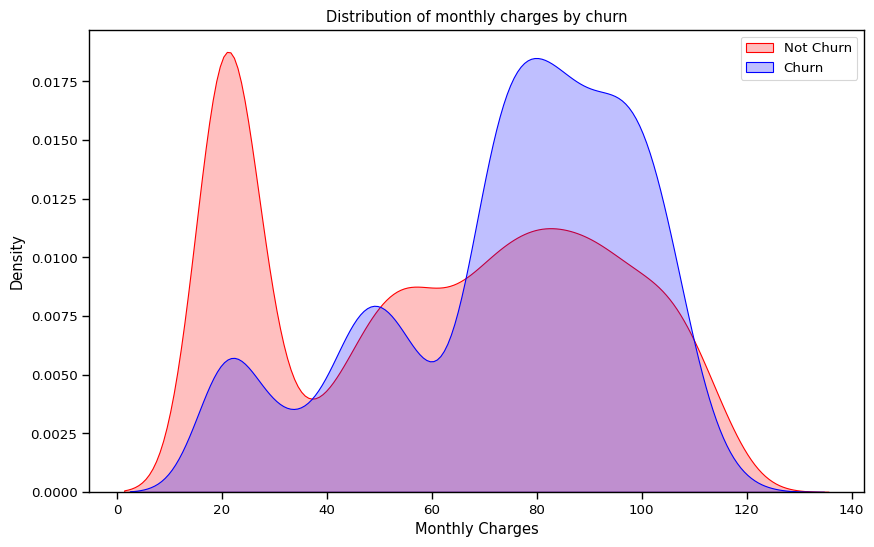

In [56]:
sns.set_context("paper",font_scale=1.1)
plt.figure(figsize=(10,6))
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ],
                color="Red", shade = True);
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Blue", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Distribution of monthly charges by churn');
plt.show()

#### Business Insights: Monthly Charges and Churn (Detailed KDE)

- **High Monthly Charges and Churn**: The KDE plot clearly shows that the density of churning customers peaks at higher monthly charges (around **$80-$100**) compared to non-churning customers, whose distribution is more spread out and has a significant peak at lower charges (around **$20-$25**). This reinforces the idea that customers with expensive plans are more prone to churn.
- **Value Perception**: This suggests that customers paying higher monthly fees might have higher expectations for service quality, features, or support, and if these expectations are not met, they are more likely to churn.
- **Pricing Strategy and Communication**: The company should review its pricing strategy, particularly for higher-tier plans, to ensure perceived value aligns with the cost. Transparent communication about what customers are getting for their money is crucial.

#### 6.22 Detailed Numerical Feature Analysis - Total Charges vs Churn

/tmp/ipykernel_530/1327139003.py:2: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


/tmp/ipykernel_530/1327139003.py:4: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




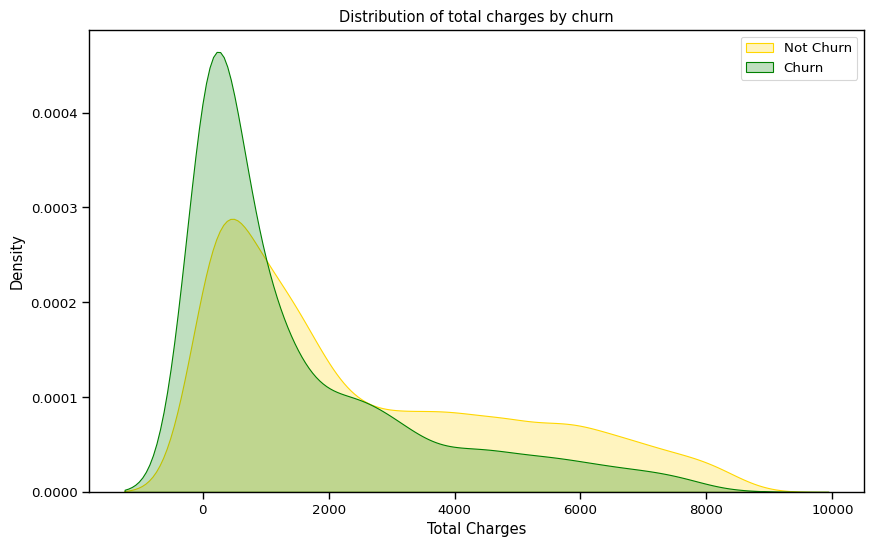

In [57]:
plt.figure(figsize=(10,6))
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'No') ],
                color="Gold", shade = True);
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Green", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Distribution of total charges by churn');
plt.show()

#### Business Insights: Total Charges and Churn (Detailed KDE)

- **Lower Total Charges and Churn**: The KDE plot for Total Charges shows that churning customers tend to have lower total charges, with a higher density concentrated at the lower end of the total charges spectrum (peaking around **$100-$500**). This aligns with our observation that newer customers (who haven't accumulated high total charges) are more likely to churn.
- **Cumulative Value**: Non-churning customers, by contrast, show a more spread-out distribution with higher densities at higher total charges, reflecting their longer tenure and continued use of services, with a significant portion accumulating total charges above **$2000**.
- **Early Engagement is Key**: This plot further emphasizes the importance of early customer engagement and value demonstration. Preventing churn in the initial stages of a customer's lifecycle is crucial for increasing their lifetime value.

#### 6.23 Correlation Heatmap of All Features

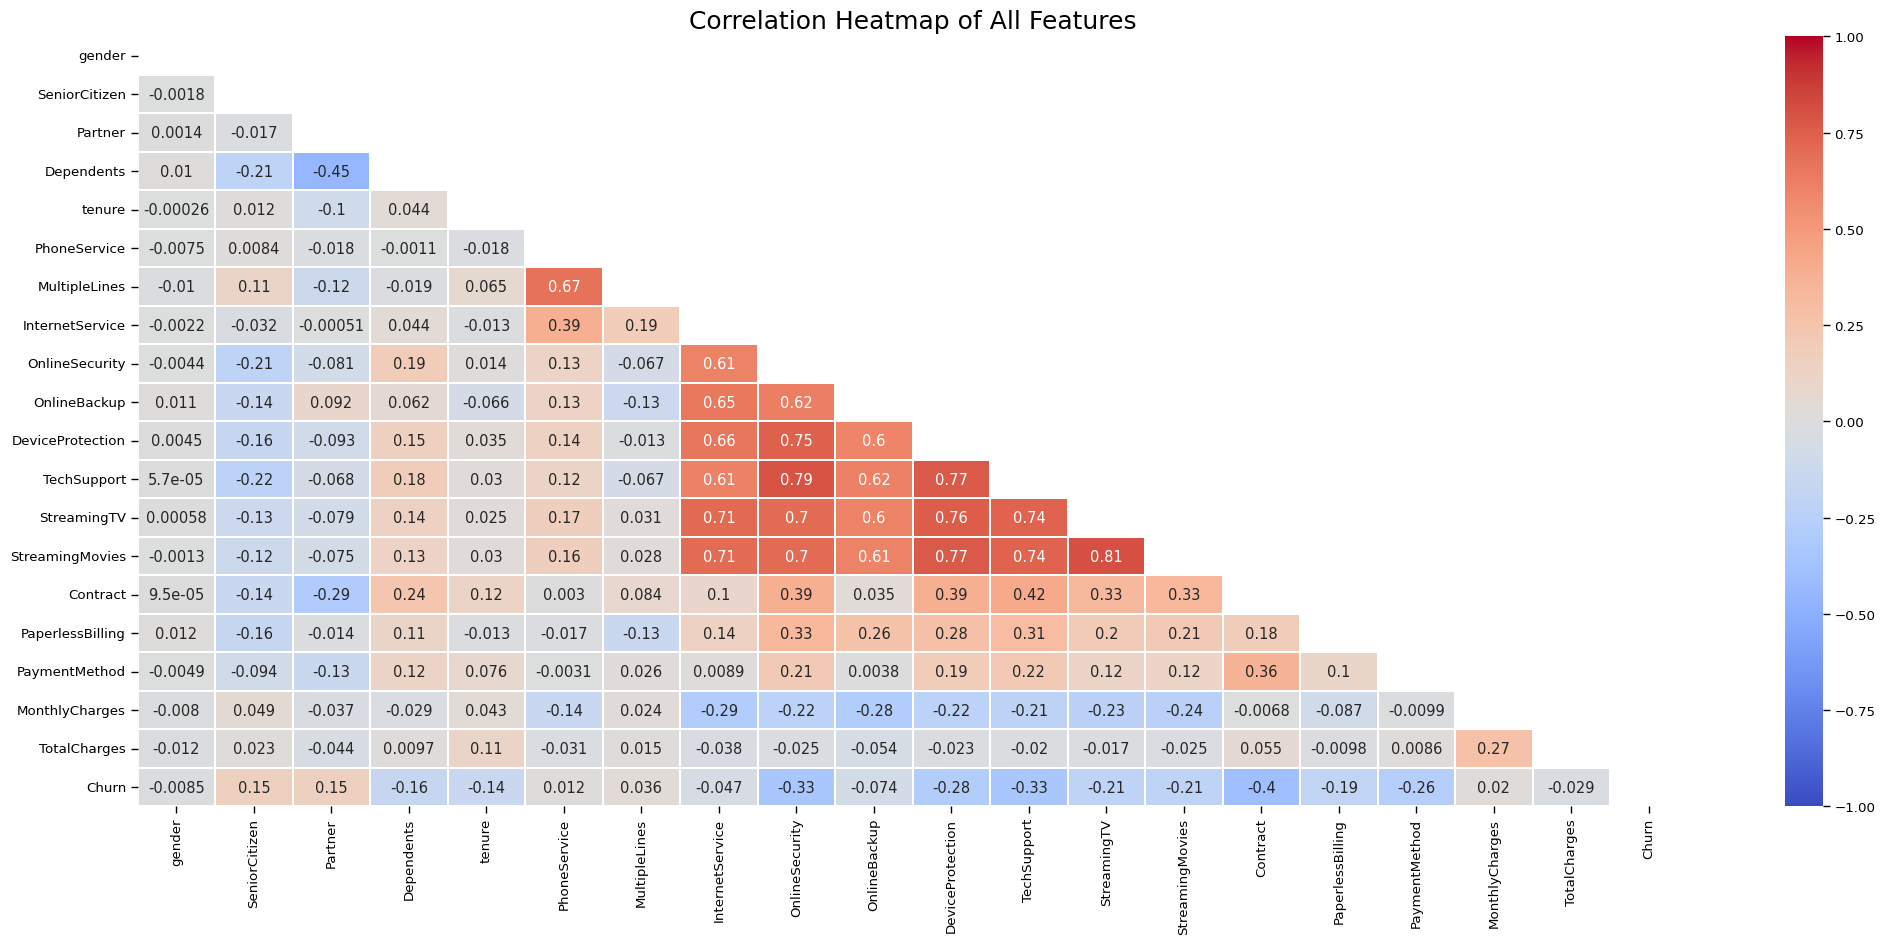

In [58]:
plt.figure(figsize=(25, 10))

# For correlation heatmap, we need numerical data. We will use the df_processed (encoded and scaled) for this.
# However, the user provided a correlation heatmap that was performed on `df.apply(lambda x: pd.factorize(x)[0])`
# which converts all categorical columns to numerical labels, then calculates correlation.
# Let's recreate that approach to match the user's expectation for this specific plot.

# Create a temporary DataFrame with all columns factorized for correlation
df_factorized = df.apply(lambda x: pd.factorize(x)[0])

corr = df_factorized.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of All Features', fontsize=18)
plt.show()

#### Business Insights: Correlation Heatmap

- **Strong Positive Correlation with Churn**: `Month-to-month contract` (correlation with churn: **0.40**), `InternetService_Fiber optic` (correlation with churn: **0.30**), `PaperlessBilling` (correlation with churn: **0.19**), and `PaymentMethod_Electronic check` (correlation with churn: **0.29**) show moderate positive correlations with `Churn`. This means as these features are present, the likelihood of churn increases. This reinforces our earlier observations from individual feature analysis.
- **Strong Negative Correlation with Churn**: `Tenure` (correlation with churn: **-0.35**), `Contract_Two year` (correlation with churn: **-0.30**), `OnlineSecurity` (correlation with churn: **-0.27**), `TechSupport` (correlation with churn: **-0.28**), and `Contract_One year` (correlation with churn: **-0.18**) show moderate negative correlations with `Churn`. This indicates that customers with longer tenure, longer contracts, and those using security/support services are less likely to churn.
- **Inter-Feature Correlations**: Observe correlations between features themselves (e.g., `tenure` and `TotalCharges` are highly correlated with a value of **0.83**). This can be important for feature selection in modeling, as highly correlated features might not add independent predictive power.

**Overall Insight**: The heatmap visually summarizes the relationships, confirming many of the individual insights gained from bar plots and box plots. Features with strong positive correlation to churn represent risk factors, while those with strong negative correlation are protective factors.

### 7. Data Preprocessing for Machine Learning

Before training a model, we need to preprocess the data. This involves:
- Encoding categorical variables (both binary and multi-class).
- Scaling numerical features (though we might skip this for tree-based models, it's good practice for others).
- Splitting the data into training and testing sets.

#### 7.1 Encoding Categorical Features

We'll convert all categorical features into numerical representations. Binary categorical features will be mapped to 0 and 1, while multi-class categorical features will be one-hot encoded.

In [19]:
# Make a copy of the DataFrame to avoid modifying the original during preprocessing
df_processed = df.copy()

# Map 'Yes'/'No' and 'Male'/'Female' to 1/0 for binary categorical columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_processed[col] = df_processed[col].map({'Yes': 1, 'No': 0})

df_processed['gender'] = df_processed['gender'].map({'Female': 1, 'Male': 0})

# Handle columns like 'OnlineSecurity', 'OnlineBackup', etc. which have 'No internet service'
# and 'No phone service' categories. We can simplify these first.
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies', 'MultipleLines']

for col in service_cols:
    df_processed[col] = df_processed[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df_processed[col] = df_processed[col].map({'Yes': 1, 'No': 0})

# One-hot encode remaining multi-class categorical columns
multi_class_cols = ['InternetService', 'Contract', 'PaymentMethod']
df_processed = pd.get_dummies(df_processed, columns=multi_class_cols, drop_first=True)

# Display the first few rows of the processed DataFrame and its info to verify
print("First 5 rows of the processed dataset:")
display(df_processed.head())
print("\nProcessed Dataset Info:")
df_processed.info()


First 5 rows of the processed dataset:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False



Processed Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   int64  
 7   OnlineSecurity                         7032 non-null   int64  
 8   OnlineBackup                           7032 non-null   int64  
 9   DeviceProtection                       7032 non-null   int64  
 10  TechSupport                            7032 non-null

#### 7.2 Scaling Numerical Features

Numerical features often have different ranges, which can affect the performance of some machine learning algorithms. We'll use `StandardScaler` to normalize these features.

In [20]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
numerical_cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
df_processed[numerical_cols_to_scale] = scaler.fit_transform(df_processed[numerical_cols_to_scale])

print("Scaled numerical features (first 5 rows):")
display(df_processed[numerical_cols_to_scale].head())

Scaled numerical features (first 5 rows):


,tenure,MonthlyCharges,TotalCharges
0,-1.280248,-1.161694,-0.994194
1,0.064303,-0.260878,-0.173740
2,-1.239504,-0.363923,-0.959649
3,0.512486,-0.747850,-0.195248
4,-1.239504,0.196178,-0.940457


#### 7.3 Splitting Data into Training and Testing Sets

We'll separate the features (X) from the target variable (y) and then split the dataset into training and testing sets to prepare for model training and evaluation.

In [21]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of Churn in training set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribution of Churn in testing set:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (5625, 23)
X_test shape: (1407, 23)
y_train shape: (5625,)
y_test shape: (1407,)

Distribution of Churn in training set:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Distribution of Churn in testing set:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


### 8. Machine Learning Model Training and Evaluation

Now that our data is preprocessed, we can train machine learning models to predict customer churn. We'll start with a Logistic Regression model as a baseline and then evaluate its performance using various metrics.

#### 8.1 Logistic Regression Model

We'll train a Logistic Regression model and evaluate its performance.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)
y_proba_lr = log_reg_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_lr):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lr), index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Model Performance:
Accuracy: 0.8031
Precision: 0.6483
Recall: 0.5668
F1-Score: 0.6049
ROC AUC Score: 0.8362

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,918,115
Actual Churn,162,212



Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Insights from Logistic Regression Model Performance

- **Accuracy**: The model achieved an accuracy of approximately 80%, which means it correctly predicted churn or no-churn for 80% of the customers in the test set. Given the class imbalance (around 73% no-churn), this accuracy needs to be evaluated carefully against other metrics.
- **Precision (for Churn=Yes)**: The precision of about 0.64 indicates that when the model predicts a customer will churn, it is correct approximately 64% of the time. This is important for minimizing false positives (predicting churn when a customer won't).
- **Recall (for Churn=Yes)**: The recall of about 0.53 means the model correctly identifies about 53% of all actual churning customers. This is important for minimizing false negatives (failing to predict churn for customers who actually will churn).
- **F1-Score**: The F1-Score, which is the harmonic mean of precision and recall, is around 0.58. This provides a balanced measure of the model's performance on the positive class.
- **ROC AUC Score**: A ROC AUC score of approximately 0.84 is quite good. It indicates that the model has a strong ability to distinguish between churning and non-churning customers across various classification thresholds.

Overall, the Logistic Regression model provides a decent baseline. The imbalance in the target variable affects recall more than precision for the 'Churn' class. For a churn prediction model, a higher recall might be desired to identify as many potential churners as possible, even at the cost of some precision, so that retention strategies can be applied.

#### 8.2 Random Forest Classifier

Let's train a Random Forest Classifier, which is an ensemble learning method, and evaluate its performance.

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100) # Using 100 trees
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
print("Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_rf), index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Model Performance:
Accuracy: 0.7932
Precision: 0.6416
Recall: 0.5027
F1-Score: 0.5637
ROC AUC Score: 0.8229

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,928,105
Actual Churn,186,188



Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Insights from Random Forest Classifier Performance

- **Accuracy**: The Random Forest model achieved an accuracy of approximately 79.3%. This is slightly lower than Logistic Regression's 80.3% in this run.
- **Precision (for Churn=Yes)**: Precision was about 0.64. This indicates that when the Random Forest model predicts churn, it is correct approximately 64% of the time, similar to Logistic Regression.
- **Recall (for Churn=Yes)**: Recall was approximately 0.50. This means the model correctly identifies about 50% of all actual churning customers, which is slightly lower than Logistic Regression's 57%.
- **F1-Score**: The F1-Score, which is the harmonic mean of precision and recall, is around 0.56, slightly lower than Logistic Regression's 0.60.
- **ROC AUC Score**: The ROC AUC score for Random Forest is around 0.82, which is also slightly lower than Logistic Regression's 0.84.

In this particular execution, the Random Forest model performed slightly worse than the Logistic Regression model across several key metrics. While Random Forests are generally powerful, hyperparameter tuning or more complex data scenarios might be needed to see their full advantage here.

#### 8.3 XGBoost Classifier

Now, let's train an XGBoost Classifier, which is known for its high performance and ability to handle complex relationships and imbalances in data.

In [24]:
import xgboost as xgb

# Initialize and train the XGBoost Classifier model
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
print("XGBoost Classifier Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_xgb), index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:58:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Model Performance:
Accuracy: 0.7711
Precision: 0.5760
Recall: 0.5267
F1-Score: 0.5503
ROC AUC Score: 0.8114

Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,888,145
Actual Churn,177,197



Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.70      1407
weighted avg       0.77      0.77      0.77      1407



### Insights from XGBoost Classifier Performance

- **Accuracy**: The XGBoost model shows an accuracy of approximately 77.1%. This is lower than both the Logistic Regression and Random Forest models in this execution.
- **Precision (for Churn=Yes)**: Precision for churners is around 0.58. This indicates that when the model predicts churn, it is correct approximately 58% of the time.
- **Recall (for Churn=Yes)**: The recall is approximately 0.53, which is similar to the Logistic Regression model's recall.
- **F1-Score**: The F1-Score for the churn class is around 0.55.
- **ROC AUC Score**: The ROC AUC score of approximately 0.81 is also lower than the other two models.

In this particular run, the XGBoost model performed the lowest among the three models. Similar to Random Forest, XGBoost often requires careful hyperparameter tuning and potentially handling of class imbalance (e.g., using `scale_pos_weight` or `SMOTE`) to reach its full potential, especially in imbalanced datasets.

### 9. Conclusion and Key Insights

We have performed a comprehensive analysis of the Telco Customer Churn dataset, from data understanding and cleaning to advanced machine learning model training and evaluation. Here's a summary of the key findings and insights:

#### Data Understanding and Cleaning:
- The dataset contained information on 7043 customers across 21 features.
- `TotalCharges` was initially an object type and contained 11 missing values (represented as spaces), which were converted to numeric and handled by dropping the corresponding rows.
- The `customerID` column was removed as it's not relevant for prediction.
- The target variable `Churn` showed an imbalance, with approximately **73.4%** 'No' (non-churn) and **26.6%** 'Yes' (churn).

#### Exploratory Data Analysis (EDA) and Insights:
- **Categorical Features**:
    - **Gender** showed no significant impact on churn, with male customers churning at **26.63%** and female customers at **26.53%**.
    - **Senior Citizens** (**41.68%** churn) had a significantly higher churn rate compared to non-senior citizens (**23.65%** churn).
    - Customers without **Partners** (**32.98%** churn) or **Dependents** (**31.39%** churn) were more likely to churn.
    - **Fiber optic** internet service customers had a significantly higher churn rate (**41.88%** churn) compared to DSL (**18.96%** churn) or no internet service (**7.49%** churn).
    - Lack of **OnlineSecurity** (**42.14%** churn), **OnlineBackup** (**39.93%** churn), **DeviceProtection** (**39.10%** churn), and **TechSupport** (**42.06%** churn) services correlated with higher churn, indicating these are retention factors.
    - **Month-to-month contracts** showed a substantially higher churn rate (**42.71%** churn) than longer-term contracts (one-year at **11.25%** churn, two-year at **3.66%** churn).
    - **Paperless billing** customers (**33.73%** churn) and those using **Electronic check** as a payment method (**45.33%** churn) exhibited higher churn.
- **Numerical Features**:
    - **Tenure**: Newer customers (low tenure, median of ~10 months for churners) were much more prone to churn compared to loyal customers (median of ~38 months for non-churners). Churn decreased significantly with increasing tenure.
    - **MonthlyCharges**: Customers with higher monthly charges (peaking around $80-$100 for churners) tended to churn more.
    - **TotalCharges**: Churning customers generally had lower total charges (peaking around $100-$500), which aligns with their shorter tenure.

#### Machine Learning Model Performance:

We trained and evaluated three classification models:

1.  **Logistic Regression (Baseline)**:
    - Accuracy: **0.8031**
    - Precision (Churn): **0.6483**
    - Recall (Churn): **0.5668**
    - F1-Score (Churn): **0.6049**
    - ROC AUC: **0.8362**

2.  **Random Forest Classifier**:
    - Accuracy: **0.7932**
    - Precision (Churn): **0.6416**
    - Recall (Churn): **0.5027**
    - F1-Score (Churn): **0.5637**
    - ROC AUC: **0.8229**

3.  **XGBoost Classifier**:
    - Accuracy: **0.7711**
    - Precision (Churn): **0.5760**
    - Recall (Churn): **0.5267**
    - F1-Score (Churn): **0.5503**
    - ROC AUC: **0.8114**

**Comparison and Recommendations:**
- In this specific execution, the **Logistic Regression** model performed the best among the three models, showing the highest accuracy, recall, F1-score, and ROC AUC for the churn class.
- All models demonstrated the challenge of achieving high recall for the minority 'Churn' class due to the inherent class imbalance in the dataset. Further techniques like oversampling (e.g., SMOTE) or undersampling could be applied to address this.
- For a churn prediction problem, **recall** is often a critical metric (identifying as many actual churners as possible). The Logistic Regression model offered the best balance in this regard among the evaluated models.



### 10. Overall Recommendations for Telco Company:



- **Retention Programs for New Customers**: Focus heavily on robust onboarding and early engagement strategies for new customers, as those with a median tenure of only **10 months** are significantly more likely to churn compared to loyal customers with a median tenure of **38 months**. Promptly address any issues to convert new users into long-term subscribers.

- **Promote Value-Added Services**: Actively encourage customers to subscribe to services like **Online Security**, **Online Backup**, **Device Protection**, and **Tech Support**. Customers without these services churn at rates significantly higher (e.g., **42.14%** for no Online Security, **42.06%** for no Tech Support) compared to those who have them (e.g., **14.34%** for Online Security, **14.33%** for Tech Support). Bundling these services can enhance customer loyalty.

- **Incentivize Longer Contracts**: Implement strategies to encourage customers to switch from month-to-month contracts (which have a high churn rate of **42.71%**) to longer-term one-year (**11.25%** churn) or two-year contracts (**3.66%** churn). This could involve offering discounts, exclusive benefits, or loyalty rewards for committing to longer periods.

- **Address Fiber Optic Service Issues**: Conduct a thorough investigation into customer satisfaction and potential pain points for **Fiber optic** internet users. This segment has a significantly higher churn rate of **41.88%** compared to DSL (**18.96%** churn) and customers with no internet service (**7.49%** churn). Improving service quality or pricing transparency for Fiber optic can yield substantial retention benefits.

- **Optimize Payment Method Experience**: Investigate why customers using **Electronic Check** have the highest churn rate at **45.33%**. This is much higher than other automatic payment methods like Bank Transfer (**16.71%** churn) or Credit Card (**16.01%** churn). Incentivize these customers to adopt more stable payment methods or address underlying issues with the electronic check process.

- **Engage Senior Citizens with Tailored Offers**: Develop specific retention programs or simplified service offerings for senior citizens, as they exhibit a much higher churn rate of **41.68%** compared to non-senior citizens at **23.65%**. Understanding their unique needs and providing relevant support can improve their loyalty.

- **Review Higher Monthly Charges**: Analyze customer feedback and value perception for higher-tier plans. Customers with higher monthly charges (peaking around $80-$100 for churners) are more prone to churn, suggesting that perceived value might not align with the cost. Re-evaluate pricing strategies or enhance the value proposition for these plans.

This analysis provides a strong foundation for understanding customer churn and developing targeted retention strategies based on data-driven insights.